In [1]:
import os
import subprocess
import sys


def pip_install(pkg: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


if not os.path.exists("argusorch"):
    subprocess.check_call(["git", "clone", "https://github.com/p4sttt/argusorch.git"])

sys.path.append(os.path.abspath("argusorch"))

pip_install("bitsandbytes>=0.43.0")
pip_install("transformers>=4.40.0")
pip_install("peft>=0.10.0")
pip_install("accelerate>=0.28.0")

In [2]:
from collections import defaultdict
import os
import time
from types import SimpleNamespace

from argusorch.agents import AgentsGroup, CentralizedCritic, LLMActor
from argusorch.agents.prompt_builder import PromptBuilder
from argusorch.env import LongHorizonPlanningEnv
from argusorch.env.rollout_collector import RolloutCollector
from argusorch.env.types import JointState
from argusorch.trainers.common import (
    ReplayBuffer,
    TD0TargetEstimator,
    TDLambdaEstimator,
)
from argusorch.trainers.maac.losses import MAACLoss
from argusorch.trainers.maac.updater import MAACUpdater
import bitsandbytes as bnb
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import peft
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

In [3]:
import sys
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
    torch.cuda.manual_seed_all(SEED)

print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Transformers:  {transformers.__version__}")
print(f"PEFT:          {peft.__version__}")
print(f"bitsandbytes:  {bnb.__version__}")
print(f"Active device: {DEVICE}")
print(f"Seed:          {SEED}")

print("\n" + "=" * 55)
print("GPU DIAGNOSTICS")
print("=" * 55)
if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    print(f"CUDA is available: {n_gpus} GPU(s)")
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        vram_gb = props.total_memory / 1024**3
        print(f"   GPU {i}: {props.name} — {vram_gb:.1f} GB VRAM")
        if vram_gb < 12:
            print("   < 12 GB: reduce max_new_tokens or use lora_r=4")
else:
    print("CUDA is unavailable — training on CPU (very slow)")

Python:        3.12.13
PyTorch:       2.11.0+cu128
Transformers:  5.0.0
PEFT:          0.19.1
bitsandbytes:  0.49.2
Active device: cuda
Seed:          42

GPU DIAGNOSTICS
CUDA is available: 1 GPU(s)
   GPU 0: Tesla T4 — 14.6 GB VRAM


In [4]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

CFG = SimpleNamespace(
    model_name="Qwen/Qwen2.5-0.5B-Instruct",
    bnb_config=bnb_config,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    max_new_tokens=32,
    temperature=0.7,
    num_epochs=40,
    actor_lr=2e-4,
    critic_lr=5e-4,
    replay_capacity=1,
    ppo_epochs=2,
    gamma=0.995,
    td_lambda=0.95,
    num_agents=2,
    max_turns=15,
    critic_chunk_size=4,
)

gen_config = {
    "max_new_tokens": CFG.max_new_tokens,
    "do_sample": True,
    "temperature": CFG.temperature,
    "pad_token_id": None,
}

dataloader = [
    {
        "goal": "Design a distributed microservices architecture for an e-commerce platform",
        "constraints": ["99.9% availability", "latency < 100ms", "GDPR compliant"],
    },
]

In [5]:
def get_model_device(model) -> torch.device:
    return next(reversed(list(model.parameters()))).device


def load_qlora_model(name: str, lora_cfg: LoraConfig) -> torch.nn.Module:
    base = AutoModelForCausalLM.from_pretrained(
        name,
        quantization_config=CFG.bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    base = prepare_model_for_kbit_training(
        base,
        use_gradient_checkpointing=True,
    )
    return get_peft_model(base, lora_cfg)


def make_paged_optimizer(model, lr: float) -> bnb.optim.PagedAdamW8bit:
    trainable = [p for p in model.parameters() if p.requires_grad]
    return bnb.optim.PagedAdamW8bit(trainable, lr=lr)


class LongHorizonPromptBuilder(PromptBuilder):
    def build(self, joint_state: JointState) -> str:
        goal = joint_state.item.get("goal", "")
        constraints = joint_state.item.get("constraints", [])
        history_lines = []
        for turn_record in joint_state.history:
            t = turn_record.get("turn", "?")
            for a_id, text in turn_record.get("actions", {}).items():
                history_lines.append(f"  [T{t}][{a_id}]: {text[:100]}")
        history_str = "\n".join(history_lines) if history_lines else "(empty)"
        constraints_str = "; ".join(constraints) if constraints else "none"
        return (
            f"[CRITIC] Long-Horizon Planning\n"
            f"Goal: {goal}\n"
            f"Constraints: {constraints_str}\n"
            f"Turn: {joint_state.turn}/{CFG.max_turns}\n"
            f"Plan History:\n{history_str}\n"
            f"Rate coherence (0.0=incoherent, 1.0=excellent):"
        )

In [6]:
tokenizer = AutoTokenizer.from_pretrained(CFG.model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
gen_config["pad_token_id"] = tokenizer.pad_token_id

lora_config = LoraConfig(
    r=CFG.lora_r,
    lora_alpha=CFG.lora_alpha,
    target_modules=CFG.target_modules,
    lora_dropout=CFG.lora_dropout,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

print("[MAS-A / TD0] Loading actor...")
actor_model_td0 = load_qlora_model(CFG.model_name, lora_config)
print("[MAS-A / TD0] Loading critic...")
critic_model_td0 = load_qlora_model(CFG.model_name, lora_config)

print("[MAS-B / TDλ] Loading actor...")
actor_model_tdl = load_qlora_model(CFG.model_name, lora_config)
print("[MAS-B / TDλ] Loading critic...")
critic_model_tdl = load_qlora_model(CFG.model_name, lora_config)

print("\nTrainable params:")
actor_model_td0.print_trainable_parameters()

if DEVICE.type == "cuda":
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserv = torch.cuda.memory_reserved() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"\nVRAM after loading 4 x QLoRA models:")
    print(f"   Allocated: {alloc:.2f} GB")
    print(f"   Reserved:  {reserv:.2f} GB")
    print(f"   Total GPU: {total:.1f} GB")
    print(f"   Available: ~{total - reserv:.1f} GB for training")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


[MAS-A / TD0] Loading actor...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[MAS-A / TD0] Loading critic...


...

[MAS-B / TDλ] Loading actor...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[MAS-B / TDλ] Loading critic...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Trainable params:
trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093

VRAM after loading 4 x QLoRA models:
   Allocated: 2.74 GB
   Reserved:  3.46 GB
   Total GPU: 14.6 GB
   Available: ~11.1 GB for training


In [7]:
def make_system_lh(actor_model, critic_model):
    env = LongHorizonPlanningEnv(max_turns=CFG.max_turns)
    a_group = AgentsGroup(
        [LLMActor(actor_model, tokenizer, gen_config) for _ in range(CFG.num_agents)]
    )
    
    critic = CentralizedCritic(critic_model, tokenizer, LongHorizonPromptBuilder())
    critic.value_head = critic.value_head.to(get_model_device(critic_model))

    collector = RolloutCollector(env, a_group, critic)
    buffer = ReplayBuffer(capacity=CFG.replay_capacity, device=DEVICE)

    actor_opt = make_paged_optimizer(actor_model, CFG.actor_lr)
    critic_opt = make_paged_optimizer(critic_model, CFG.critic_lr)

    actors_dict = {f"agent_{i}": a for i, a in enumerate(a_group.actors)}
    actor_opts = {f"agent_{i}": actor_opt for i in range(CFG.num_agents)}

    updater = MAACUpdater(
        actors_dict,
        critic,
        actor_opts,
        critic_opt,
        MAACLoss(),
        ppo_epochs=CFG.ppo_epochs,
        device=DEVICE,
        critic_chunk_size=CFG.critic_chunk_size,
    )
    return collector, buffer, updater, a_group, critic


estimator_td0 = TD0TargetEstimator(gamma=CFG.gamma)
collector_td0, buffer_td0, updater_td0, agents_td0, critic_td0 = make_system_lh(
    actor_model_td0, critic_model_td0
)

estimator_tdl = TDLambdaEstimator(gamma=CFG.gamma, lambda_=CFG.td_lambda)
collector_tdl, buffer_tdl, updater_tdl, agents_tdl, critic_tdl = make_system_lh(
    actor_model_tdl, critic_model_tdl
)

print("Both MAS initialized successfully")

Both MAS initialized successfully


In [8]:
log_td0 = defaultdict(list)
log_tdl = defaultdict(list)
steps_log = []
adv_std_td0 = []
adv_std_tdl = []
update_steps_td0 = []
update_steps_tdl = []

print(f"Starting training: {CFG.num_epochs} epochs x {len(dataloader)} task(s)")
print("-" * 78)

t_start = time.time()
global_step = 0


def run_step_track_adv(collector, estimator, buffer, updater, batch) -> tuple:
    traj, env_metrics = collector.collect(batch)
    targets = estimator.compute(traj)
    buffer.add(traj, targets)
    metrics = env_metrics.copy()

    advantages = []
    for agent_traj in targets.by_agent():
        for t in agent_traj:
            advantages.append(t.advantage)
    adv_std = float(np.std(advantages)) if advantages else 0.0

    if buffer.ready():
        train_batch = buffer.sample()
        update_metrics = updater.update(train_batch)
        metrics.update(update_metrics)

    return metrics, adv_std


for epoch in range(CFG.num_epochs):
    for batch in dataloader:
        m_td0, std_td0 = run_step_track_adv(collector_td0, estimator_td0, buffer_td0, updater_td0, batch)
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        m_tdl, std_tdl = run_step_track_adv(collector_tdl, estimator_tdl, buffer_tdl, updater_tdl, batch)
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        global_step += 1
        steps_log.append(global_step)
        adv_std_td0.append(std_td0)
        adv_std_tdl.append(std_tdl)

        if "critic_loss" in m_td0:
            update_steps_td0.append(global_step)
        if "critic_loss" in m_tdl:
            update_steps_tdl.append(global_step)

        for k, v in m_td0.items():
            if isinstance(v, float):
                log_td0[k].append(v)
        for k, v in m_tdl.items():
            if isinstance(v, float):
                log_tdl[k].append(v)

        elapsed = time.time() - t_start
        c_td0 = m_td0.get("critic_loss", float("nan"))
        c_tdl = m_tdl.get("critic_loss", float("nan"))
        r_td0 = m_td0.get("reward", float("nan"))
        r_tdl = m_tdl.get("reward", float("nan"))
        print(
            f"[E{epoch+1:02d}/{CFG.num_epochs} S{global_step:03d}] "
            f"TD0: c={c_td0:.4f} r={r_td0:.1f} sigma={std_td0:.4f}  "
            f"| TDlambda: c={c_tdl:.4f} r={r_tdl:.1f} sigma={std_tdl:.4f}  "
            f"{elapsed:.1f}s"
        )

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        alloc = torch.cuda.memory_allocated() / 1024**3
        reserv = torch.cuda.memory_reserved() / 1024**3
        print(f"\tVRAM: alloc={alloc:.2f} GB, reserved={reserv:.2f} GB")

total_time = time.time() - t_start
print(f"\nTraining completed in {total_time:.1f}s ({total_time/60:.1f} min)")

Starting training: 40 epochs x 1 task(s)
------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[E01/40 S001] TD0: c=6.1376 r=4.5 sigma=1.9403  | TDlambda: c=111.0507 r=4.5 sigma=2.7084  221.3s
	VRAM: alloc=2.77 GB, reserved=3.41 GB
[E02/40 S002] TD0: c=4.0315 r=4.6 sigma=1.3623  | TDlambda: c=77.1654 r=4.5 sigma=1.8846  439.5s
	VRAM: alloc=2.77 GB, reserved=3.41 GB
[E03/40 S003] TD0: c=3.1780 r=4.5 sigma=1.5027  | TDlambda: c=76.9912 r=4.5 sigma=2.3604  655.7s
	VRAM: alloc=2.77 GB, reserved=3.41 GB
[E04/40 S004] TD0: c=4.3526 r=4.5 sigma=2.3873  | TDlambda: c=106.1321 r=4.6 sigma=2.9333  872.7s
	VRAM: alloc=2.77 GB, reserved=3.42 GB
[E05/40 S005] TD0: c=8.2938 r=4.7 sigma=2.1473  | TDlambda: c=84.6269 r=4.5 sigma=2.6544  1089.9s
	VRAM: alloc=2.77 GB, reserved=3.42 GB
[E06/40 S006] TD0: c=8.5643 r=4.5 sigma=1.3661  | TDlambda: c=90.8902 r=4.5 sigma=2.8206  1310.0s
	VRAM: alloc=2.77 GB, reserved=3.41 GB
[E07/40 S007] TD0: c=6.6890 r=4.5 sigma=2.0581  | TDlambda: c=66.1915 r=4.5 sigma=2.1648  1530.8s
	VRAM: alloc=2.77 GB, reserved=3.41 GB
[E08/40 S008] TD0: c=3.3373 r=4.7 sigma=1.9

/tmp/ipykernel_28021/131998110.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


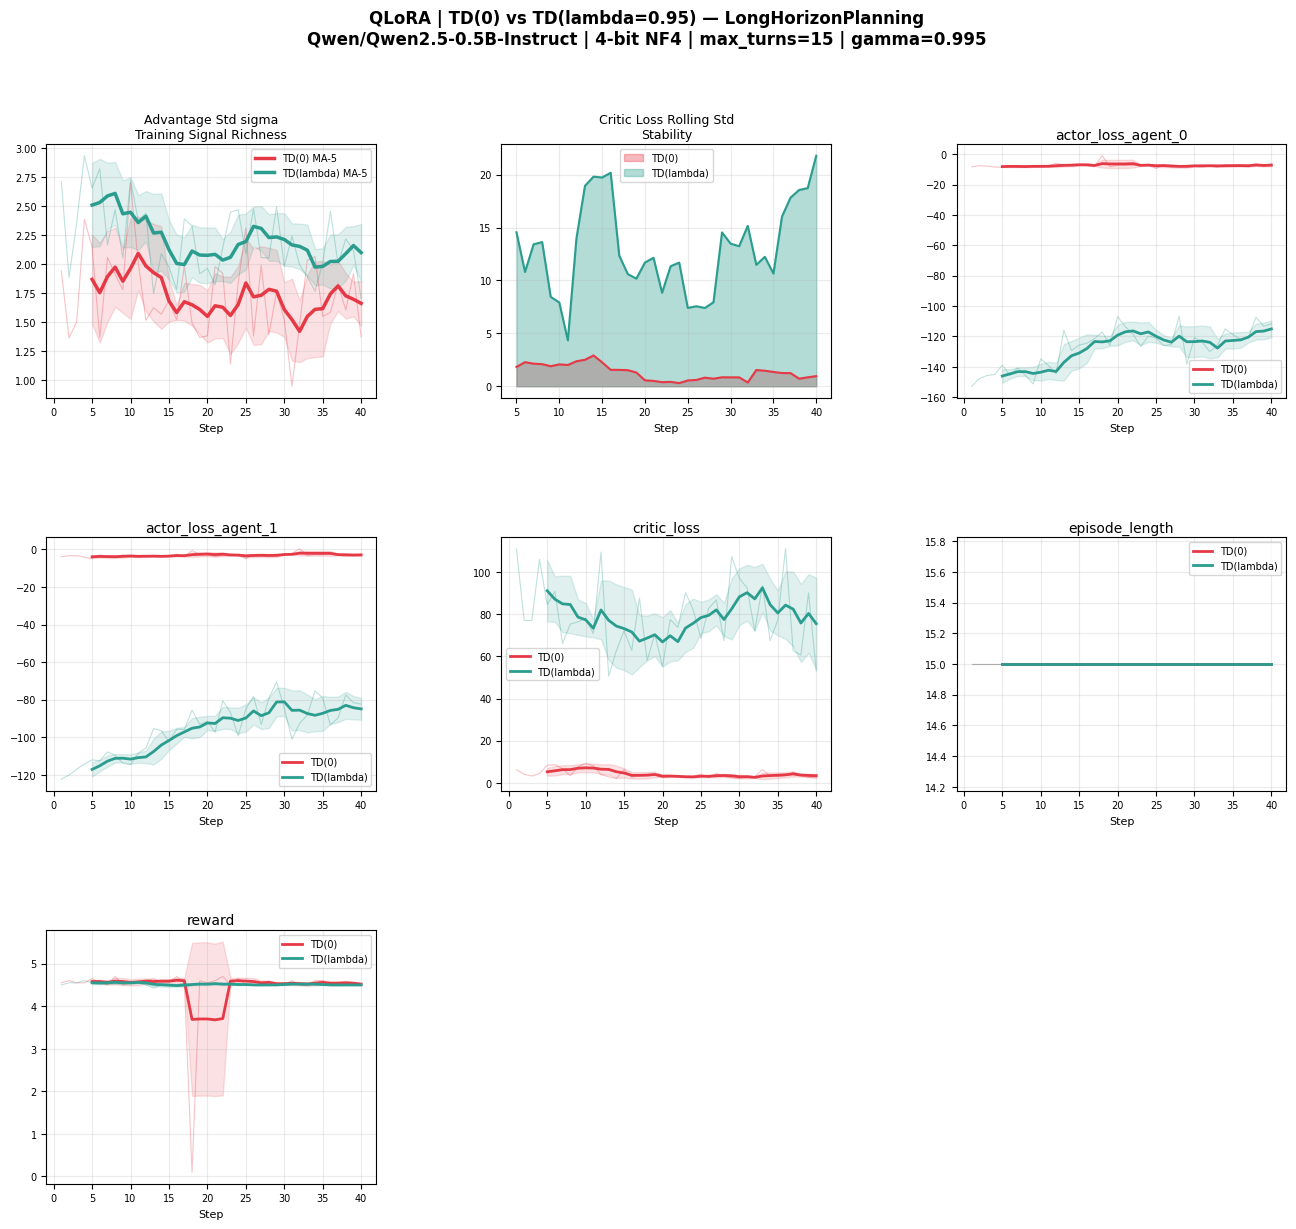

In [9]:
def moving_avg(x: list, w: int = 5) -> np.ndarray:
    arr = np.array(x, dtype=float)
    return arr if len(arr) < w else np.convolve(arr, np.ones(w) / w, mode="valid")


def rolling_std(x: list, w: int = 5) -> np.ndarray:
    arr = np.array(x, dtype=float)
    return np.array([arr[i : i + w].std() for i in range(len(arr) - w + 1)])


COLOR_TD0 = "#e63946"
COLOR_TDL = "#2a9d8f"
WINDOW = max(3, min(len(steps_log) // 8, 10))

all_keys = sorted(set(log_td0.keys()) | set(log_tdl.keys()))
n_panels = 2 + len(all_keys)
cols = 3
rows = (n_panels + cols - 1) // cols

fig = plt.figure(figsize=(16, 4.5 * rows))
fig.suptitle(
    f"QLoRA | TD(0) vs TD(lambda={CFG.td_lambda}) — LongHorizonPlanning\n"
    f"{CFG.model_name} | 4-bit NF4 | max_turns={CFG.max_turns} | gamma={CFG.gamma}",
    fontsize=12,
    fontweight="bold",
)
gs = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.55, wspace=0.38)

ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(steps_log, adv_std_td0, color=COLOR_TD0, lw=0.8, alpha=0.3)
ax0.plot(steps_log, adv_std_tdl, color=COLOR_TDL, lw=0.8, alpha=0.3)
if len(adv_std_td0) >= WINDOW:
    ma0 = moving_avg(adv_std_td0, WINDOW)
    mal = moving_avg(adv_std_tdl, WINDOW)
    std0 = rolling_std(adv_std_td0, WINDOW)
    stdl = rolling_std(adv_std_tdl, WINDOW)
    ax0.plot(steps_log[WINDOW - 1 :], ma0, color=COLOR_TD0, lw=2.5, label=f"TD(0) MA-{WINDOW}")
    ax0.fill_between(
        steps_log[WINDOW - 1 :], ma0 - std0, ma0 + std0, color=COLOR_TD0, alpha=0.15
    )
    ax0.plot(steps_log[WINDOW - 1 :], mal, color=COLOR_TDL, lw=2.5, label=f"TD(lambda) MA-{WINDOW}")
    ax0.fill_between(
        steps_log[WINDOW - 1 :], mal - stdl, mal + stdl, color=COLOR_TDL, alpha=0.15
    )
ax0.set_title("Advantage Std sigma\nTraining Signal Richness", fontsize=9, pad=4)
ax0.set_xlabel("Step", fontsize=8)
ax0.legend(fontsize=7)
ax0.grid(True, alpha=0.25)
ax0.tick_params(labelsize=7)

ax1 = fig.add_subplot(gs[0, 1])
if "critic_loss" in log_td0 and len(log_td0["critic_loss"]) >= WINDOW:
    var0 = rolling_std(log_td0["critic_loss"], WINDOW)
    varl = rolling_std(log_tdl.get("critic_loss", [0.0] * len(steps_log)), WINDOW)
    xs_v = steps_log[WINDOW - 1 :]
    ax1.fill_between(xs_v[: len(var0)], 0, var0, color=COLOR_TD0, alpha=0.35, label="TD(0)")
    ax1.fill_between(xs_v[: len(varl)], 0, varl, color=COLOR_TDL, alpha=0.35, label="TD(lambda)")
    ax1.plot(xs_v[: len(var0)], var0, color=COLOR_TD0, lw=1.5)
    ax1.plot(xs_v[: len(varl)], varl, color=COLOR_TDL, lw=1.5)
ax1.set_title("Critic Loss Rolling Std\nStability", fontsize=9, pad=4)
ax1.set_xlabel("Step", fontsize=8)
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.25)
ax1.tick_params(labelsize=7)

for idx, key in enumerate(all_keys):
    pos = idx + 2
    ax = fig.add_subplot(gs[pos // cols, pos % cols])
    for vals, color, label in [
        (log_td0.get(key, []), COLOR_TD0, "TD(0)"),
        (log_tdl.get(key, []), COLOR_TDL, "TD(lambda)"),
    ]:
        if not vals:
            continue
        xs_cut = steps_log[-len(vals) :]
        ax.plot(xs_cut, vals, color=color, lw=0.8, alpha=0.3)
        if len(vals) >= WINDOW:
            ma_vals = moving_avg(vals, WINDOW)
            std_vals = rolling_std(vals, WINDOW)
            ax.plot(xs_cut[WINDOW - 1 :], ma_vals, color=color, lw=2, label=label)
            ax.fill_between(
                xs_cut[WINDOW - 1 :],
                ma_vals - std_vals,
                ma_vals + std_vals,
                color=color,
                alpha=0.15,
            )
    ax.set_title(key, fontsize=10, pad=4)
    ax.set_xlabel("Step", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("long_horizon.png", dpi=150, bbox_inches="tight")
plt.show()